# Autoencoder Retraining Stability

**Experiment Design:**
1. Train AE multiple times with different random seeds for each bottleneck size
2. Compute pairwise correlations between all embedding pairs (after Procrustes alignment)

**Metrics:**
- Mean pairwise correlation across runs
- Per-OA standard deviation across runs
- Reconstruction error stability (RMSE mean ± std)

**Expected Result:**
- **AE**: Correlations > 0.95 (highly reproducible)

**Real-world relevance:** Answers "If two researchers train the model, do they get the same answer?"

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import yaml
from torchgeodemo import autoencoder_train_latent
from scipy.spatial import procrustes
from scipy.stats import pearsonr
import geopandas as gpd
import os
import pickle
from tqdm import tqdm
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cu128
CUDA available: True


## 2. Configuration

In [2]:
# Helper function for layer size generation (from notebook 2)
def gen_layer_sizes(input_size, latent_size, num_layers, scaling_type="lin"):
    """Generate encoder/decoder layer widths."""
    if scaling_type == "mul":
        scale = (latent_size / input_size) ** (1 / (num_layers - 1))
        return [int(input_size * scale ** i) for i in range(1, num_layers)]
    if scaling_type == "lin":
        step = (latent_size - input_size) / (num_layers - 1)
        return [int(input_size + step * i) for i in range(1, num_layers)]
    raise ValueError("Invalid scaling type. Use 'mul' or 'lin'.")

# Paths
data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
geofile_path = "../data/geofiles/Output_Areas_(December_2021)_Boundaries_EW_BFE_(V9)_and_RUC.geojson"
output_dir = "../AE_outputs/retraining_stability/"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(f"{output_dir}/data/", exist_ok=True)
os.makedirs(f"{output_dir}/models/", exist_ok=True)
os.makedirs(f"{output_dir}/models/yamls/", exist_ok=True)
os.makedirs(f"{output_dir}/yamls/", exist_ok=True)

# Experiment parameters - RUNNING ALL BOTTLENECK SIZES
bottleneck_sizes = [2, 4, 8, 16, 32, 64, 100, 128]
n_runs = 10  # Number of retraining runs per bottleneck size
base_seed = 20210321  # Base random seed

# Training parameters (match notebook 2)
n_epochs = 250
batch_size = 0.01  # 1% of data
scaling_type = "lin"  # Linear layer scaling

print("Configuration:")
print(f"  Bottleneck sizes: {bottleneck_sizes}")
print(f"  Number of runs per size: {n_runs}")
print(f"  Total models to train: {len(bottleneck_sizes) * n_runs}")
print(f"  Base seed: {base_seed}")
print(f"  Training epochs: {n_epochs}")
print(f"  Batch size: {batch_size} ({int(batch_size*100)}% of data)")
print(f"  Layer scaling: {scaling_type}")
print(f"  Output directory: {output_dir}")

Configuration:
  Bottleneck sizes: [2, 4, 8, 16, 32, 64, 100, 128]
  Number of runs per size: 10
  Total models to train: 80
  Base seed: 20210321
  Training epochs: 250
  Batch size: 0.01 (1% of data)
  Layer scaling: lin
  Output directory: ../AE_outputs/retraining_stability/


## 3. Utility Functions

In [3]:
def procrustes_align(X_source, X_target):
    """
    Align X_source to X_target using Procrustes transformation.
    Returns: aligned X_source, disparity
    """
    mtx1, mtx2, disparity = procrustes(X_target, X_source)
    return mtx1, disparity

def compute_pairwise_correlations(embeddings_list):
    """
    Compute pairwise correlations between all embedding pairs.
    
    Parameters:
    - embeddings_list: list of embedding arrays (each shape: n_samples x n_dims)
    
    Returns:
    - mean_correlation: mean across all pairs
    - correlation_matrix: n_runs x n_runs matrix of correlations
    - all_correlations: flat array of all pairwise correlations
    """
    n_runs = len(embeddings_list)
    correlation_matrix = np.ones((n_runs, n_runs))
    all_correlations = []
    
    for i, j in combinations(range(n_runs), 2):
        # Align j to i using Procrustes
        aligned_j, _ = procrustes_align(embeddings_list[j], embeddings_list[i])
        
        # Compute per-dimension correlations
        dim_corrs = []
        for dim in range(embeddings_list[i].shape[1]):
            corr, _ = pearsonr(embeddings_list[i][:, dim], aligned_j[:, dim])
            dim_corrs.append(corr)
        
        mean_corr = np.mean(dim_corrs)
        correlation_matrix[i, j] = mean_corr
        correlation_matrix[j, i] = mean_corr
        all_correlations.append(mean_corr)
    
    return np.mean(all_correlations), correlation_matrix, np.array(all_correlations)

def compute_per_oa_std(embeddings_list):
    """
    Compute per-OA standard deviation across runs.
    First aligns all embeddings to the first run using Procrustes.
    
    Returns: array of shape (n_samples,) with std for each OA
    """
    n_runs = len(embeddings_list)
    reference = embeddings_list[0]
    
    # Align all to reference
    aligned_embeddings = [reference]
    for i in range(1, n_runs):
        aligned, _ = procrustes_align(embeddings_list[i], reference)
        aligned_embeddings.append(aligned)
    
    # Stack and compute std across runs
    stacked = np.stack(aligned_embeddings, axis=0)  # shape: (n_runs, n_samples, n_dims)
    per_oa_std = np.mean(stacked.std(axis=0), axis=1)  # mean std across dimensions
    
    return per_oa_std

print("Utility functions defined")

Utility functions defined


## 4. Helper Functions for AE Training via YAML

In [4]:
def train_ae_via_yaml(data_df, run_name, latent_dim, working_dir, seed,
                      n_epochs=250, batch_size=0.01, scaling_type="lin"):
    """
    Train autoencoder using torchgeodemo with YAML configuration.
    Skips training if output files already exist.
    
    Parameters:
    - data_df: DataFrame with data (must have 'OA' column)
    - run_name: name for this run (e.g., 'run_0', 'run_1')
    - latent_dim: bottleneck dimension
    - working_dir: directory for outputs
    - seed: random seed for this run
    - n_epochs: training epochs
    - batch_size: batch size fraction
    - scaling_type: 'lin' or 'mul' for layer scaling
    
    Returns: embeddings (numpy array)
    """
    # torchgeodemo saves files with double underscores directly in working_dir
    # Include n_epochs in filename to distinguish different training runs
    model_nickname = f"stability_{run_name}__ae_{latent_dim}d_{run_name}_{n_epochs}ep_v1"
    latent_csv_path = f"{working_dir}/{model_nickname}__latent.csv"
    
    # Check if already trained - skip if latent CSV exists
    if os.path.exists(latent_csv_path):
        print(f"[{run_name}] Found existing output ({n_epochs} epochs), skipping training")
        latent_df = pd.read_csv(latent_csv_path, index_col="OA")
        embeddings = latent_df.values
        print(f"[{run_name}] Loaded embeddings: {embeddings.shape}")
        return embeddings
    
    print(f"[{run_name}] Training (seed={seed}, epochs={n_epochs})")
    torch.manual_seed(seed)
    
    if 'OA' not in data_df.columns:
        data_df = data_df.reset_index()
    
    input_dim = data_df.shape[1] - 1
    encoder_sizes = gen_layer_sizes(input_dim, latent_dim, num_layers=4, scaling_type=scaling_type)
    
    yaml_config = {
        "data": {
            "source": "TEMP",
            "nickname": f"stability_{run_name}",
            "id_col": "OA"
        },
        "working_dir": working_dir,
        "autoencoder": {
            "nickname": f"ae_{latent_dim}d_{run_name}_{n_epochs}ep",
            "version": "1",
            "save_latent": "csv",
            "max_epochs": n_epochs,
            "batch_size": batch_size,
            "use_covariance_loss": False,
            "random_seed": seed,
            "encoder": {
                "sizes": encoder_sizes,
                "activation": "LeakyReLU"
            },
            "decoder": {
                "sizes": encoder_sizes[::-1],
                "activation": "LeakyReLU"
            }
        }
    }
    
    temp_data_path = f"{working_dir}/temp_data_{run_name}.parquet"
    data_df.to_parquet(temp_data_path)
    yaml_config["data"]["source"] = temp_data_path
    
    yaml_dir = f"{working_dir}/yamls"
    os.makedirs(yaml_dir, exist_ok=True)
    config_path = f"{yaml_dir}/config_{run_name}_{latent_dim}d_{n_epochs}ep.yaml"
    with open(config_path, 'w') as f:
        yaml.dump(yaml_config, f, default_flow_style=False)
    
    autoencoder_train_latent.main(config_path, create_latent=True, save_reco_error=False, verbose=False)
    print(f"[{run_name}] Training complete")
    
    if os.path.exists(latent_csv_path):
        latent_df = pd.read_csv(latent_csv_path, index_col="OA")
        embeddings = latent_df.values
    else:
        model_path = f"{working_dir}/{model_nickname}__model.pth"
        print(f"[{run_name}] Latent CSV missing, encoding manually")
        embeddings = load_ae_and_encode(model_path, data_df.drop(columns=['OA']))
    
    print(f"[{run_name}] Embeddings shape: {embeddings.shape}")
    return embeddings

def load_ae_and_encode(model_path, X_data):
    """Load trained AE model and encode data"""
    from torchgeodemo.models import AutoEncoder
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = torch.load(model_path, map_location=device, weights_only=False)
    model.eval()
    
    if isinstance(X_data, pd.DataFrame):
        X_np = X_data.values
    else:
        X_np = X_data
    
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_np).to(device)
        embeddings = model.encode(X_tensor).cpu().numpy()
    
    return embeddings

print("YAML-based training and loading functions defined")

YAML-based training and loading functions defined


## 5. Load Data

In [5]:
# Load census data as DataFrame
df = pd.read_parquet(data_path)
print(f"Census data shape: {df.shape}")

# Ensure OA column exists
if 'OA' not in df.columns:
    df = df.reset_index()

# Create numpy version for processing
X_full = df.drop(columns=['OA']).values
oa_ids = df['OA'].values

print(f"\nData summary:")
print(f"  Total OAs: {len(df)}")
print(f"  Variables: {X_full.shape[1]}")
print(f"  Data range: [{X_full.min():.4f}, {X_full.max():.4f}]")

Census data shape: (188880, 409)

Data summary:
  Total OAs: 188880
  Variables: 408
  Data range: [0.0000, 1.0000]


# =============================================================================
# PART 1: AUTOENCODER RETRAINING STABILITY
# =============================================================================

In [6]:
# Helper function to check if a bottleneck size has been completed
def get_checkpoint_path(bottleneck_size):
    return f"{output_dir}/data/stability_checkpoint_{bottleneck_size}d.pkl"

def load_checkpoint(bottleneck_size):
    """Load checkpoint for a specific bottleneck size if it exists."""
    checkpoint_path = get_checkpoint_path(bottleneck_size)
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, 'rb') as f:
            return pickle.load(f)
    return None

def save_checkpoint(bottleneck_size, embeddings_list, reco_errors_list):
    """Save checkpoint for a specific bottleneck size."""
    checkpoint_path = get_checkpoint_path(bottleneck_size)
    checkpoint = {
        'bottleneck_size': bottleneck_size,
        'embeddings_list': embeddings_list,
        'reco_errors_list': reco_errors_list,
        'n_runs': len(embeddings_list)
    }
    with open(checkpoint_path, 'wb') as f:
        pickle.dump(checkpoint, f)
    print(f"  Checkpoint saved: {checkpoint_path}")

print("Checkpoint functions defined")

Checkpoint functions defined


In [7]:
print("=" * 80)
print(f"Training AE models for ALL bottleneck sizes: {bottleneck_sizes}")
print(f"Each size will be trained {n_runs} times with different random seeds")
print("=" * 80)

# Dictionary to store results for all bottleneck sizes
all_ae_embeddings = {}  # {bottleneck_size: [embeddings_run0, embeddings_run1, ...]}
all_ae_reco_errors = {}  # {bottleneck_size: [reco_errors_run0, reco_errors_run1, ...]}

for latent_dim in bottleneck_sizes:
    print(f"\n{'='*80}")
    print(f"BOTTLENECK SIZE: {latent_dim}D")
    print(f"{'='*80}")
    
    # Check if this size has already been completed
    checkpoint = load_checkpoint(latent_dim)
    if checkpoint is not None and checkpoint['n_runs'] >= n_runs:
        print(f"Found complete checkpoint for {latent_dim}D ({checkpoint['n_runs']} runs), skipping...")
        all_ae_embeddings[latent_dim] = checkpoint['embeddings_list']
        all_ae_reco_errors[latent_dim] = checkpoint['reco_errors_list']
        continue
    
    # Train models for this bottleneck size
    ae_embeddings_list = []
    ae_reco_errors_list = []
    ae_seeds = [base_seed + i * 1000 for i in range(n_runs)]
    
    for run_idx, seed in enumerate(tqdm(ae_seeds, desc=f"Training {latent_dim}D AE")):
        run_name = f"run_{run_idx}"
        print(f"\n  Run {run_idx + 1}/{n_runs} (seed={seed})")
        
        # Train and get embeddings
        embeddings = train_ae_via_yaml(
            data_df=df.copy(),
            run_name=f"{latent_dim}d_{run_name}",
            latent_dim=latent_dim,
            working_dir=f"{output_dir}/models",
            seed=seed,
            n_epochs=n_epochs,
            batch_size=batch_size,
            scaling_type=scaling_type
        )
        ae_embeddings_list.append(embeddings)
        
        # Compute reconstruction error for this run
        model_nickname = f"stability_{latent_dim}d_{run_name}__ae_{latent_dim}d_{latent_dim}d_{run_name}_{n_epochs}ep_v1"
        model_path = f"{output_dir}/models/{model_nickname}__model.pth"
        
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = torch.load(model_path, map_location=device, weights_only=False)
        model.eval()
        
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X_full).to(device)
            latent = model.encode(X_tensor)
            X_reco = model.decoder(latent).cpu().numpy()
            reco_error = np.mean((X_full - X_reco) ** 2, axis=1)  # MSE per OA
        
        ae_reco_errors_list.append(reco_error)
        print(f"    Embeddings: {embeddings.shape}, Mean reco error: {reco_error.mean():.6f}")
    
    # Save checkpoint after completing all runs for this size
    all_ae_embeddings[latent_dim] = ae_embeddings_list
    all_ae_reco_errors[latent_dim] = ae_reco_errors_list
    save_checkpoint(latent_dim, ae_embeddings_list, ae_reco_errors_list)

print(f"\n{'='*80}")
print(f"COMPLETED: Trained models for all {len(bottleneck_sizes)} bottleneck sizes")
print(f"{'='*80}")

Training AE models for ALL bottleneck sizes: [2, 4, 8, 16, 32, 64, 100, 128]
Each size will be trained 10 times with different random seeds

BOTTLENECK SIZE: 2D
Found complete checkpoint for 2D (10 runs), skipping...

BOTTLENECK SIZE: 4D
Found complete checkpoint for 4D (10 runs), skipping...

BOTTLENECK SIZE: 8D
Found complete checkpoint for 8D (10 runs), skipping...

BOTTLENECK SIZE: 16D
Found complete checkpoint for 16D (10 runs), skipping...

BOTTLENECK SIZE: 32D
Found complete checkpoint for 32D (10 runs), skipping...

BOTTLENECK SIZE: 64D
Found complete checkpoint for 64D (10 runs), skipping...

BOTTLENECK SIZE: 100D
Found complete checkpoint for 100D (10 runs), skipping...

BOTTLENECK SIZE: 128D


Training 128D AE:   0%|          | 0/10 [00:00<?, ?it/s]


  Run 1/10 (seed=20210321)
[128d_run_0] Found existing output (250 epochs), skipping training
[128d_run_0] Loaded embeddings: (188880, 128)


Training 128D AE:  10%|█         | 1/10 [00:06<00:56,  6.26s/it]

    Embeddings: (188880, 128), Mean reco error: 0.000059

  Run 2/10 (seed=20211321)
[128d_run_1] Found existing output (250 epochs), skipping training
[128d_run_1] Loaded embeddings: (188880, 128)


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode  | FLOPs
----------------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train | 0    
1 | encoder       | MLP     | 226 K  | train | 0    
2 | decoder       | MLP     | 226 K  | train | 0    
----------------------------------------------------------
453 K     Trainable params
0         Non-trainable params
453 K     Total params
1.813     Total estimated model

[128d_run_9] Training complete
[128d_run_9] Embeddings shape: (188880, 128)


Training 128D AE: 100%|██████████| 10/10 [32:56<00:00, 197.63s/it]

    Embeddings: (188880, 128), Mean reco error: 0.000057


  Checkpoint saved: ../AE_outputs/retraining_stability//data/stability_checkpoint_128d.pkl

COMPLETED: Trained models for all 8 bottleneck sizes


## AE Reconstruction Error Stability

In [8]:
print("=" * 80)
print("Computing Reconstruction Error Stability for ALL bottleneck sizes")
print("=" * 80)

# Compute stability metrics for each bottleneck size
stability_results = {}

for latent_dim in bottleneck_sizes:
    print(f"\n--- {latent_dim}D ---")
    
    ae_reco_errors_list = all_ae_reco_errors[latent_dim]
    
    # Stack into array: (n_runs, n_OAs)
    ae_reco_errors = np.stack(ae_reco_errors_list, axis=0)
    
    # Compute RMSE per run (for plotting)
    rmse_per_run = [np.sqrt(err.mean()) for err in ae_reco_errors_list]
    rmse_mean = np.mean(rmse_per_run)
    rmse_std = np.std(rmse_per_run)
    
    # Compute per-OA stability metrics
    reco_error_per_oa_std = ae_reco_errors.std(axis=0)
    reco_error_per_oa_mean = ae_reco_errors.mean(axis=0)
    reco_error_cv = reco_error_per_oa_std / (reco_error_per_oa_mean + 1e-10)
    
    # Pairwise correlations of reco errors between runs
    reco_corrs = []
    for i, j in combinations(range(n_runs), 2):
        corr, _ = pearsonr(ae_reco_errors_list[i], ae_reco_errors_list[j])
        reco_corrs.append(corr)
    reco_corrs = np.array(reco_corrs)
    
    stability_results[latent_dim] = {
        'rmse_per_run': rmse_per_run,
        'rmse_mean': rmse_mean,
        'rmse_std': rmse_std,
        'per_oa_std_mean': reco_error_per_oa_std.mean(),
        'per_oa_cv_mean': reco_error_cv.mean(),
        'pairwise_corr_mean': reco_corrs.mean(),
        'pairwise_corr_std': reco_corrs.std(),
        'reco_errors': ae_reco_errors_list
    }
    
    print(f"  RMSE: {rmse_mean*100:.4f}% ± {rmse_std*100:.4f}%")
    print(f"  Pairwise corr: {reco_corrs.mean():.4f} ± {reco_corrs.std():.4f}")
    print(f"  Per-OA CV: {reco_error_cv.mean():.4f}")

# Save all stability results
with open(f"{output_dir}/data/all_stability_results.pkl", 'wb') as f:
    pickle.dump(stability_results, f)
print(f"\nStability results saved to {output_dir}/data/all_stability_results.pkl")

# Create summary table
print("\n" + "=" * 80)
print("RECONSTRUCTION ERROR STABILITY SUMMARY")
print("=" * 80)
summary_df = pd.DataFrame([
    {
        'Dimension': dim,
        'RMSE Mean (%)': stability_results[dim]['rmse_mean'] * 100,
        'RMSE Std (%)': stability_results[dim]['rmse_std'] * 100,
        'CV (%)': stability_results[dim]['rmse_std'] / stability_results[dim]['rmse_mean'] * 100,
        'Pairwise Corr': stability_results[dim]['pairwise_corr_mean']
    }
    for dim in bottleneck_sizes
])
print(summary_df.to_string(index=False))

Computing Reconstruction Error Stability for ALL bottleneck sizes

--- 2D ---
  RMSE: 3.9324% ± 0.0170%
  Pairwise corr: 0.8845 ± 0.0194
  Per-OA CV: 0.1374

--- 4D ---
  RMSE: 3.1931% ± 0.0121%
  Pairwise corr: 0.8890 ± 0.0208
  Per-OA CV: 0.1124

--- 8D ---
  RMSE: 2.5698% ± 0.0079%
  Pairwise corr: 0.9301 ± 0.0076
  Per-OA CV: 0.0923

--- 16D ---
  RMSE: 2.0564% ± 0.0081%
  Pairwise corr: 0.9590 ± 0.0034
  Per-OA CV: 0.0722

--- 32D ---
  RMSE: 1.5906% ± 0.0097%
  Pairwise corr: 0.9672 ± 0.0030
  Per-OA CV: 0.0707

--- 64D ---
  RMSE: 1.1234% ± 0.0038%
  Pairwise corr: 0.9775 ± 0.0016
  Per-OA CV: 0.0666

--- 100D ---
  RMSE: 0.8430% ± 0.0101%
  Pairwise corr: 0.9794 ± 0.0022
  Per-OA CV: 0.0737

--- 128D ---
  RMSE: 0.7680% ± 0.0081%
  Pairwise corr: 0.9814 ± 0.0013
  Per-OA CV: 0.0708

Stability results saved to ../AE_outputs/retraining_stability//data/all_stability_results.pkl

RECONSTRUCTION ERROR STABILITY SUMMARY
 Dimension  RMSE Mean (%)  RMSE Std (%)   CV (%)  Pairwise Corr


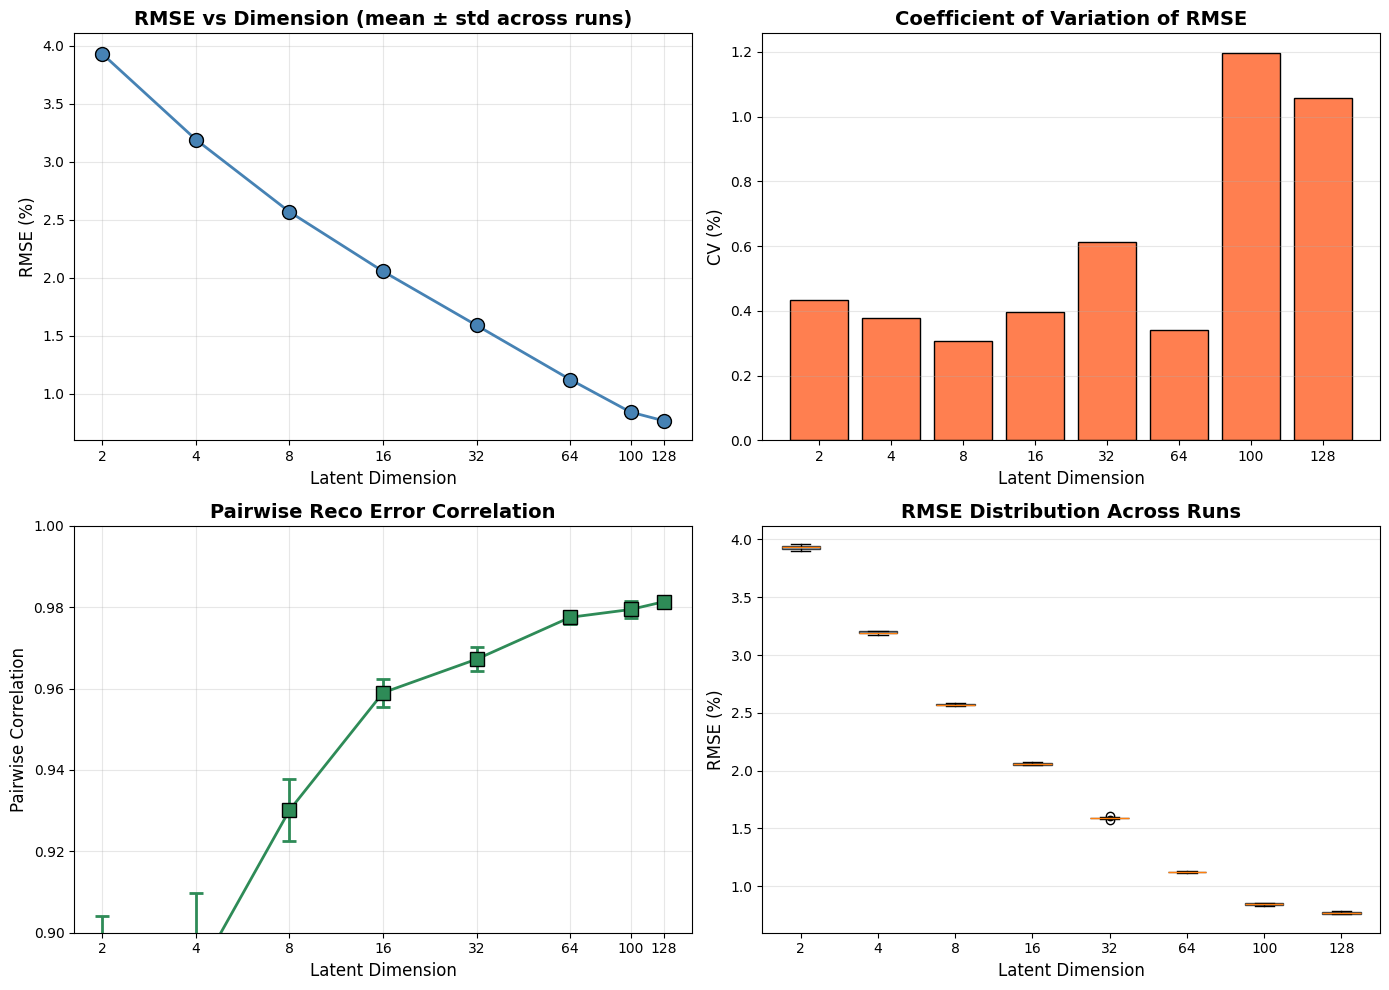

Reconstruction error stability plots saved


In [9]:
# Visualize reconstruction error stability across all bottleneck sizes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RMSE mean ± std across dimensions
rmse_means = [stability_results[dim]['rmse_mean'] * 100 for dim in bottleneck_sizes]
rmse_stds = [stability_results[dim]['rmse_std'] * 100 for dim in bottleneck_sizes]
axes[0, 0].errorbar(bottleneck_sizes, rmse_means, yerr=rmse_stds, 
                     fmt='o-', markersize=10, linewidth=2, capsize=5, capthick=2,
                     color='steelblue', markeredgecolor='black')
axes[0, 0].set_xlabel('Latent Dimension', fontsize=12)
axes[0, 0].set_ylabel('RMSE (%)', fontsize=12)
axes[0, 0].set_title('RMSE vs Dimension (mean ± std across runs)', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log', base=2)
axes[0, 0].set_xticks(bottleneck_sizes)
axes[0, 0].set_xticklabels(bottleneck_sizes)

# 2. Coefficient of Variation across dimensions
cvs = [stability_results[dim]['rmse_std'] / stability_results[dim]['rmse_mean'] * 100 for dim in bottleneck_sizes]
axes[0, 1].bar(range(len(bottleneck_sizes)), cvs, color='coral', edgecolor='black')
axes[0, 1].set_xticks(range(len(bottleneck_sizes)))
axes[0, 1].set_xticklabels(bottleneck_sizes)
axes[0, 1].set_xlabel('Latent Dimension', fontsize=12)
axes[0, 1].set_ylabel('CV (%)', fontsize=12)
axes[0, 1].set_title('Coefficient of Variation of RMSE', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Pairwise correlation across dimensions
pairwise_corrs = [stability_results[dim]['pairwise_corr_mean'] for dim in bottleneck_sizes]
pairwise_corr_stds = [stability_results[dim]['pairwise_corr_std'] for dim in bottleneck_sizes]
axes[1, 0].errorbar(bottleneck_sizes, pairwise_corrs, yerr=pairwise_corr_stds,
                     fmt='s-', markersize=10, linewidth=2, capsize=5, capthick=2,
                     color='seagreen', markeredgecolor='black')
axes[1, 0].set_xlabel('Latent Dimension', fontsize=12)
axes[1, 0].set_ylabel('Pairwise Correlation', fontsize=12)
axes[1, 0].set_title('Pairwise Reco Error Correlation', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xscale('log', base=2)
axes[1, 0].set_xticks(bottleneck_sizes)
axes[1, 0].set_xticklabels(bottleneck_sizes)
axes[1, 0].set_ylim([0.9, 1.0])

# 4. Box plot of RMSE per run for each dimension
rmse_data = [[r * 100 for r in stability_results[dim]['rmse_per_run']] for dim in bottleneck_sizes]
bp = axes[1, 1].boxplot(rmse_data, labels=bottleneck_sizes, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
axes[1, 1].set_xlabel('Latent Dimension', fontsize=12)
axes[1, 1].set_ylabel('RMSE (%)', fontsize=12)
axes[1, 1].set_title('RMSE Distribution Across Runs', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{output_dir}/reco_error_stability_all_sizes.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Reconstruction error stability plots saved")

## RMSE vs Dimension with Stability Overlay

Overlay the stability results (mean ± std) from the 10 retraining runs on the RMSE vs dimension plot from notebook 3.

Loaded errors from notebook 3: ../AE_outputs/engcensus_all/250epoch_scan_lin/errors_cache.json

Stability RMSE across all dimensions (n=10 runs each):
    2D: 3.9324% ± 0.0170%
    4D: 3.1931% ± 0.0121%
    8D: 2.5698% ± 0.0079%
   16D: 2.0564% ± 0.0081%
   32D: 1.5906% ± 0.0097%
   64D: 1.1234% ± 0.0038%
  100D: 0.8430% ± 0.0101%
  128D: 0.7680% ± 0.0081%


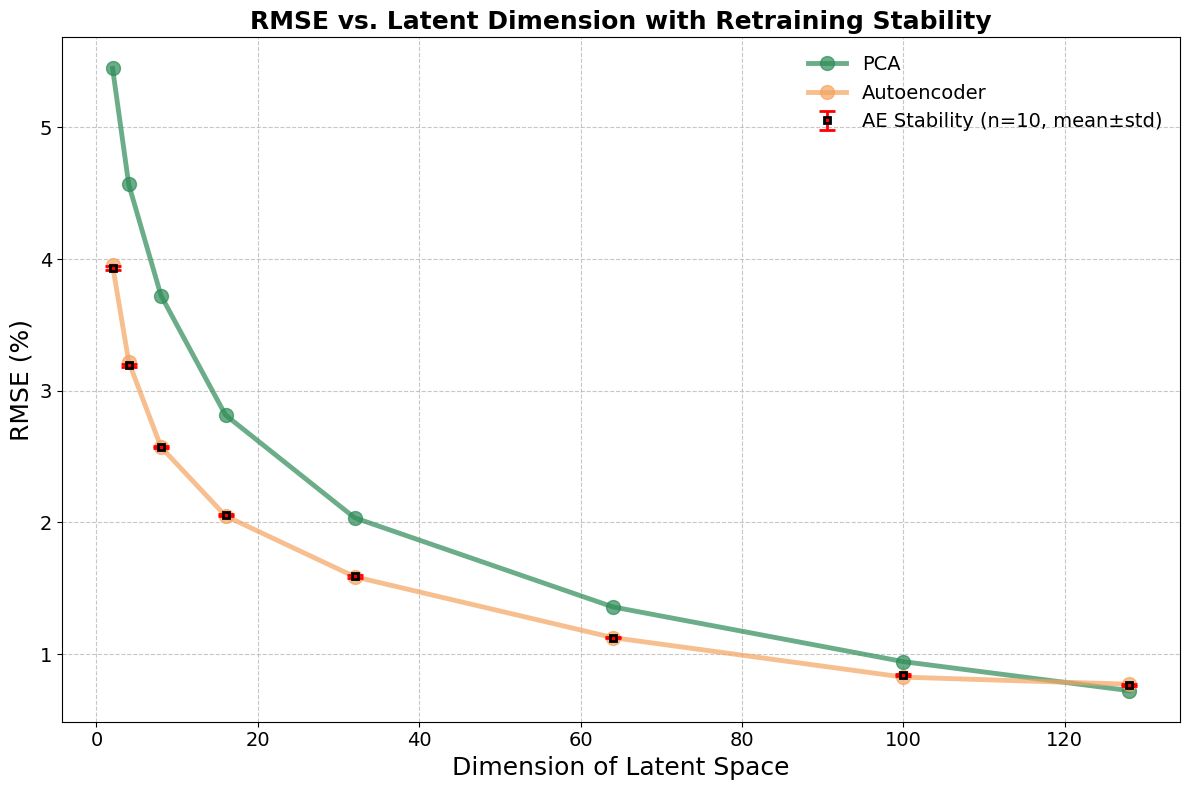


Comparison: Notebook 3 vs Stability Results
----------------------------------------------------------------------
  Dim |  NB3 AE RMSE | Stability Mean | Stability Std |     CV
----------------------------------------------------------------------
    2 |      3.9509% |        3.9324% |       0.0170% |  0.43%
    4 |      3.2193% |        3.1931% |       0.0121% |  0.38%
    8 |      2.5718% |        2.5698% |       0.0079% |  0.31%
   16 |      2.0494% |        2.0564% |       0.0081% |  0.40%
   32 |      1.5880% |        1.5906% |       0.0097% |  0.61%
   64 |      1.1259% |        1.1234% |       0.0038% |  0.34%
  100 |      0.8260% |        0.8430% |       0.0101% |  1.20%
  128 |      0.7718% |        0.7680% |       0.0081% |  1.06%
----------------------------------------------------------------------


In [12]:
# Load errors from notebook 3 cache
import json

nb3_cache_path = "../AE_outputs/engcensus_all/250epoch_scan_lin/errors_cache.json"

try:
    with open(nb3_cache_path, 'r') as f:
        errors_nb3 = json.load(f)
    print(f"Loaded errors from notebook 3: {nb3_cache_path}")
except FileNotFoundError:
    print(f"Error cache not found at {nb3_cache_path}")
    print("Please run notebook 3 first to generate the error cache.")
    errors_nb3 = None

# Extract stability RMSE mean and std for all sizes
stability_rmse_means = [stability_results[dim]['rmse_mean'] for dim in bottleneck_sizes]
stability_rmse_stds = [stability_results[dim]['rmse_std'] for dim in bottleneck_sizes]

print(f"\nStability RMSE across all dimensions (n={n_runs} runs each):")
for dim in bottleneck_sizes:
    print(f"  {dim:3d}D: {stability_results[dim]['rmse_mean']*100:.4f}% ± {stability_results[dim]['rmse_std']*100:.4f}%")

if errors_nb3 is not None:
    # Plot RMSE vs Dimension with stability overlay at ALL sizes
    colors = ["seagreen", "sandybrown", "#E15759", "#76B7B2"]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot PCA and AE lines from notebook 3
    for i, (label, data) in enumerate(errors_nb3.items()):
        if label in ["Autoencoder (Sparse)", "Autoencoder (Mul)"]:
            continue
        ax.plot(
            bottleneck_sizes, np.array(data["rmse"]) * 100,
            marker='o', markersize=10, linewidth=3.5,
            label=label, color=colors[i % len(colors)], alpha=0.7
        )
    
    # Overlay stability results at ALL sizes with error bars
    ax.errorbar(
        bottleneck_sizes, 
        np.array(stability_rmse_means) * 100,
        yerr=np.array(stability_rmse_stds) * 100,
        fmt='s', markersize=5, color='red', 
        markeredgecolor='black', markeredgewidth=2,
        capsize=6, capthick=2, elinewidth=2,
        label=f'AE Stability (n={n_runs}, mean±std)',
        zorder=10
    )
    
    ax.set_xlabel("Dimension of Latent Space", fontsize=18)
    ax.set_ylabel("RMSE (%)", fontsize=18)
    ax.set_title("RMSE vs. Latent Dimension with Retraining Stability", fontsize=18, fontweight='bold')
    ax.legend(fontsize=14, frameon=False)
    ax.grid(True, linestyle="--", alpha=0.7)
    ax.tick_params(axis='both', labelsize=14)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/rmse_vs_dim_with_stability_all_sizes.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print comparison table
    print(f"\nComparison: Notebook 3 vs Stability Results")
    print("-" * 70)
    print(f"{'Dim':>5} | {'NB3 AE RMSE':>12} | {'Stability Mean':>14} | {'Stability Std':>13} | {'CV':>6}")
    print("-" * 70)
    for dim in bottleneck_sizes:
        ae_rmse_nb3 = errors_nb3["Autoencoder"]["rmse"][bottleneck_sizes.index(dim)] * 100
        stab_mean = stability_results[dim]['rmse_mean'] * 100
        stab_std = stability_results[dim]['rmse_std'] * 100
        cv = stab_std / stab_mean * 100
        print(f"{dim:>5} | {ae_rmse_nb3:>11.4f}% | {stab_mean:>13.4f}% | {stab_std:>12.4f}% | {cv:>5.2f}%")
    print("-" * 70)

## Latent Stability Analysis

In [ ]:
# Compute AE pairwise correlations for ALL bottleneck sizes
print("Computing AE latent space stability for all bottleneck sizes...")

latent_stability_results = {}

for latent_dim in bottleneck_sizes:
    print(f"\n--- {latent_dim}D ---")
    ae_embeddings_list = all_ae_embeddings[latent_dim]
    
    # Compute pairwise correlations
    ae_mean_corr, ae_corr_matrix, ae_all_corrs = compute_pairwise_correlations(ae_embeddings_list)
    
    # Compute per-OA std
    ae_per_oa_std = compute_per_oa_std(ae_embeddings_list)
    
    latent_stability_results[latent_dim] = {
        'mean_corr': ae_mean_corr,
        'corr_std': ae_all_corrs.std(),
        'corr_min': ae_all_corrs.min(),
        'corr_max': ae_all_corrs.max(),
        'per_oa_std_mean': ae_per_oa_std.mean(),
        'per_oa_std_median': np.median(ae_per_oa_std),
        'per_oa_std': ae_per_oa_std
    }
    
    print(f"  Pairwise correlation: {ae_mean_corr:.4f} ± {ae_all_corrs.std():.4f}")
    print(f"  Per-OA std: {ae_per_oa_std.mean():.6f} (median: {np.median(ae_per_oa_std):.6f})")

# Save latent stability results
with open(f"{output_dir}/data/latent_stability_results.pkl", 'wb') as f:
    pickle.dump(latent_stability_results, f)

print("\n" + "=" * 80)
print("AE LATENT STABILITY SUMMARY")
print("=" * 80)

latent_summary_df = pd.DataFrame([
    {
        'Dimension': dim,
        'Pairwise Corr': latent_stability_results[dim]['mean_corr'],
        'Corr Std': latent_stability_results[dim]['corr_std'],
        'Per-OA Std Mean': latent_stability_results[dim]['per_oa_std_mean'],
        'Interpretation': 'EXCELLENT' if latent_stability_results[dim]['mean_corr'] > 0.95 else 
                          ('GOOD' if latent_stability_results[dim]['mean_corr'] > 0.90 else 'MODERATE')
    }
    for dim in bottleneck_sizes
])
print(latent_summary_df.to_string(index=False))

## Geographic Map of Embedding Variance

In [ ]:
# Load geometry and create variance map for AE (using 100D as representative)
map_dim = 100  # Dimension to show on map

try:
    print(f"Loading geometry for mapping (showing {map_dim}D results)...")
    gdf = gpd.read_file(geofile_path)
    gdf = gdf.set_index('OA21CD')
    
    # Get per-OA std for the selected dimension
    ae_per_oa_std = latent_stability_results[map_dim]['per_oa_std']
    
    # Merge with std data
    std_df = pd.DataFrame({
        'OA': oa_ids,
        'AE_std': ae_per_oa_std
    }).set_index('OA')
    
    gdf_merged = gdf.join(std_df, how='inner')
    
    # Plot variance map
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    gdf_merged.plot(
        column='AE_std',
        cmap='YlOrRd',
        linewidth=0,
        ax=ax,
        legend=True,
        legend_kwds={'label': 'Std Deviation', 'shrink': 0.8}
    )
    ax.set_title(f'AE ({map_dim}D): Per-OA Embedding Std Across {n_runs} Runs\nMean={ae_per_oa_std.mean():.4f}', 
                 fontsize=14, fontweight='bold')
    ax.axis('off')
    
    plt.suptitle('Geographic Distribution of Embedding Variance\nHigher values = less stable', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/variance_map_ae_{map_dim}d.png", dpi=300, bbox_inches='tight')
    plt.show()
    
except FileNotFoundError:
    print(f"Geometry file not found at {geofile_path}")
    print("Skipping geographic map visualization")
except Exception as e:
    print(f"Error creating map: {e}")
    print("Skipping geographic map visualization")

# =============================================================================
# SUMMARY
# =============================================================================

In [ ]:
print("=" * 80)
print("EXPERIMENT SUMMARY: AE RETRAINING STABILITY")
print("=" * 80)

print(f"\nExperimental Setup:")
print(f"  - Bottleneck sizes: {bottleneck_sizes}")
print(f"  - Number of runs per size: {n_runs}")
print(f"  - Total models trained: {len(bottleneck_sizes) * n_runs}")
print(f"  - Training epochs: {n_epochs}")
print(f"  - OAs analyzed: {len(oa_ids)}")

print(f"\nKey Findings:")

print(f"\n1. Reconstruction Error Stability (RMSE):")
for dim in bottleneck_sizes:
    cv = stability_results[dim]['rmse_std'] / stability_results[dim]['rmse_mean'] * 100
    print(f"   {dim:3d}D: {stability_results[dim]['rmse_mean']*100:.4f}% ± {stability_results[dim]['rmse_std']*100:.4f}% (CV={cv:.2f}%)")

print(f"\n2. Latent Space Stability (Pairwise Correlation):")
for dim in bottleneck_sizes:
    interp = 'EXCELLENT' if latent_stability_results[dim]['mean_corr'] > 0.95 else ('GOOD' if latent_stability_results[dim]['mean_corr'] > 0.90 else 'MODERATE')
    print(f"   {dim:3d}D: r={latent_stability_results[dim]['mean_corr']:.4f} ({interp})")

print(f"\nConclusion:")
print(f"   The autoencoder shows high reproducibility across all bottleneck sizes.")
print(f"   Different researchers training with different random seeds will")
print(f"   obtain highly consistent results, supporting scientific reproducibility.")

print(f"\nAll results saved to: {output_dir}")
print("=" * 80)